# Projeto Prático: Análise de Redes Complexas com Python e NetworkX

**Disciplina:** Comunicação e Redes  
**Aluno / Autor:** Rodrigo Ramos  
**Rede Analisada:** Rede Neural Cortical de Felino (`bn-cat-mixed-species_brain_1`)  
**Data:** 2026

---


## 1. Importação das Bibliotecas

Para a realização deste trabalho prático individual, utilizei a biblioteca **NetworkX**, padrão no ecossistema Python para análise e modelagem de grafos e redes complexas. Também utilizei **Matplotlib** para a geração dos gráficos de distribuição e topologia de rede, além de **Pandas** e **NumPy** para auxílio no tratamento estatístico dos dados.


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configurações visuais dos gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Bibliotecas importadas com sucesso!")
print("Versão do NetworkX:", nx.__version__)


Bibliotecas importadas com sucesso!
Versão do NetworkX: 3.6.1


## 2. Carregamento e Caracterização da Rede Real

Nesta etapa, carrego o arquivo `bn-cat-mixed-species_brain_1.edges`. Este dataset representa o mapa de conexões corticais (conectoma) do cérebro de um gato, extraído de dados biológicos reais.

O arquivo segue a estrutura de lista de arestas (*edgelist*), onde cada linha lista um par de nós conectados por uma aresta. O comando `nx.read_edgelist` lê o arquivo e monta a estrutura de grafo não-direcionado em memória.


In [2]:
# Carregando o arquivo da rede real (.edges)
caminho_arquivo = 'bn-cat-mixed-species_brain_1.edges'

# nx.read_edgelist carrega a lista de arestas criando o grafo não-direcionado
G_real = nx.read_edgelist(caminho_arquivo, create_using=nx.Graph(), nodetype=int)

print("Rede real carregada com sucesso!")
print(f"Instância do Grafo: {G_real}")


Rede real carregada com sucesso!
Instância do Grafo: Graph with 65 nodes and 730 edges


## 3. Análise Básica da Rede Real

De acordo com as orientações do projeto prático, calculei as 3 métricas fundamentais para a rede real:

1. **Ordem ($N$)**: Quantidade de nós (regiões corticais) do grafo.
2. **Coeficiente de Agrupamento Médio ($C$)**: Média dos coeficientes de agrupamento locais dos nós. Mede o grau em que os vizinhos de um nó tendem a se conectar entre si.
3. **Densidade ($ho$)**: Razão entre a quantidade de arestas existentes e a quantidade máxima possível de arestas para um grafo simples de $N$ nós.


In [3]:
# 1. Ordem (número de nós)
ordem_real = G_real.number_of_nodes()

# 2. Coeficiente de Agrupamento Médio (average clustering coefficient)
clustering_real = nx.average_clustering(G_real)

# 3. Densidade da rede (density)
densidade_real = nx.density(G_real)

# Exibindo os resultados da rede real
print("=== MÉTRICAS BÁSICAS DA REDE REAL ===")
print(f" - Ordem (Número de Nós - N): {ordem_real}")
print(f" - Coeficiente de Agrupamento Médio (C): {clustering_real:.4f}")
print(f" - Densidade (ρ): {densidade_real:.4f}")


=== MÉTRICAS BÁSICAS DA REDE REAL ===
 - Ordem (Número de Nós - N): 65
 - Coeficiente de Agrupamento Médio (C): 0.3575
 - Densidade (ρ): 0.3510


## 4. Geração e Comparação com Rede Aleatória (Erdős-Rényi)

Para verificar se a estrutura da rede biológica se comporta diferente de uma rede puramente aleatória, criei um grafo aleatório utilizando o modelo de **Erdős-Rényi** $G(N, M)$.

Para uma comparação justa, a rede aleatória foi gerada com **exatamente a mesma ordem** ($N = 65$) e **mesmo número de arestas** ($M = 730$) da rede real. Em seguida, calculei as mesmas 3 medidas básicas.


In [4]:
# Resgatando ordem e tamanho exatos da rede real
tamanho_real = G_real.number_of_edges()

# Geração de grafo aleatório com mesmo N e M (Erdős-Rényi)
seed_aleatoria = 42
G_aleatorio = nx.gnm_random_graph(n=ordem_real, m=tamanho_real, seed=seed_aleatoria)

# Calculando as métricas para a rede aleatória
ordem_aleat = G_aleatorio.number_of_nodes()
clustering_aleat = nx.average_clustering(G_aleatorio)
densidade_aleat = nx.density(G_aleatorio)

print("=== MÉTRICAS BÁSICAS DA REDE ALEATÓRIA (Erdős-Rényi) ===")
print(f" - Ordem (Número de Nós - N): {ordem_aleat}")
print(f" - Coeficiente de Agrupamento Médio (C): {clustering_aleat:.4f}")
print(f" - Densidade (ρ): {densidade_aleat:.4f}")


=== MÉTRICAS BÁSICAS DA REDE ALEATÓRIA (Erdős-Rényi) ===
 - Ordem (Número de Nós - N): 65
 - Coeficiente de Agrupamento Médio (C): 0.3470
 - Densidade (ρ): 0.3510


## 5. Análise Adicional 1: Modelo de Pequeno Mundo (Watts-Strogatz)

Como **primeira análise adicional**, escolhi explorar o modelo de **Pequeno Mundo** (*Small-World Network*), proposto por Watts e Strogatz. 

Redes biológicas e neurais costumam apresentar a chamada "propriedade de pequeno mundo", caracterizada por um alto agrupamento local (formação de módulos) e, ao mesmo tempo, curtos caminhos de separação entre quaisquer dois nós.

Gerei uma rede Watts-Strogatz mantendo a ordem $N = 65$, grau médio $k \approx \frac{2M}{N}$ e uma probabilidade de reconexão aleatória $p = 0.1$.


In [5]:
# Grau médio aproximado dos nós (k = 2M / N)
k_medio = int(round(2 * tamanho_real / ordem_real))

# Gerando rede Watts-Strogatz (Pequeno Mundo)
p_reconexao = 0.1
G_smallworld = nx.watts_strogatz_graph(n=ordem_real, k=k_medio, p=p_reconexao, seed=42)

# Calculando as métricas da rede de pequeno mundo
ordem_sw = G_smallworld.number_of_nodes()
clustering_sw = nx.average_clustering(G_smallworld)
densidade_sw = nx.density(G_smallworld)

print("=== MÉTRICAS BÁSICAS - REDE PEQUENO MUNDO (Watts-Strogatz) ===")
print(f" - Ordem (Número de Nós - N): {ordem_sw}")
print(f" - Coeficiente de Agrupamento Médio (C): {clustering_sw:.4f}")
print(f" - Densidade (ρ): {densidade_sw:.4f}")


=== MÉTRICAS BÁSICAS - REDE PEQUENO MUNDO (Watts-Strogatz) ===
 - Ordem (Número de Nós - N): 65
 - Coeficiente de Agrupamento Médio (C): 0.5762
 - Densidade (ρ): 0.3438


## 6. Análise Adicional 2: Distribuição de Graus, Diâmetro e Grau Médio de Separação

Como **segunda análise adicional**, realizei uma investigação complementar focada em:

1. **Diâmetro da Rede**: A maior distância (menor caminho) entre qualquer par de nós navegáveis.
2. **Grau Médio de Separação (Caminho Mínimo Médio - $L$)**: O número médio de passos necessários para ir de um nó a qualquer outro na rede.
3. **Distribuição de Graus ($P(k)$)**: Gráfico histograma comparando a frequência com que diferentes graus de conexão aparecem na rede real em relação ao modelo aleatório.


In [6]:
# Função para calcular diâmetro e menor caminho médio
def obter_metricas_caminhos(g):
    if nx.is_connected(g):
        diam = nx.diameter(g)
        caminho_medio = nx.average_shortest_path_length(g)
    else:
        # Se houver nós isolados, calcula no maior componente conexo
        maior_comp = max(nx.connected_components(g), key=len)
        sub_g = g.subgraph(maior_comp)
        diam = nx.diameter(sub_g)
        caminho_medio = nx.average_shortest_path_length(sub_g)
    return diam, caminho_medio

diam_real, path_real = obter_metricas_caminhos(G_real)
diam_aleat, path_aleat = obter_metricas_caminhos(G_aleatorio)
diam_sw, path_sw = obter_metricas_caminhos(G_smallworld)

print("=== DIÂMETRO E GRAU MÉDIO DE SEPARAÇÃO (CAMINHO MÍNIMO MÉDIO) ===")
print(f"1. Rede Real (Cérebro do Gato):   Diâmetro = {diam_real}, Caminho Médio (L) = {path_real:.4f}")
print(f"2. Rede Aleatória (Erdős-Rényi):   Diâmetro = {diam_aleat}, Caminho Médio (L) = {path_aleat:.4f}")
print(f"3. Rede Pequeno Mundo (Watts-Strg): Diâmetro = {diam_sw}, Caminho Médio (L) = {path_sw:.4f}")


=== DIÂMETRO E GRAU MÉDIO DE SEPARAÇÃO (CAMINHO MÍNIMO MÉDIO) ===
1. Rede Real (Cérebro do Gato):   Diâmetro = 3, Caminho Médio (L) = 1.6495
2. Rede Aleatória (Erdős-Rényi):   Diâmetro = 2, Caminho Médio (L) = 1.6490
3. Rede Pequeno Mundo (Watts-Strg): Diâmetro = 3, Caminho Médio (L) = 1.6846


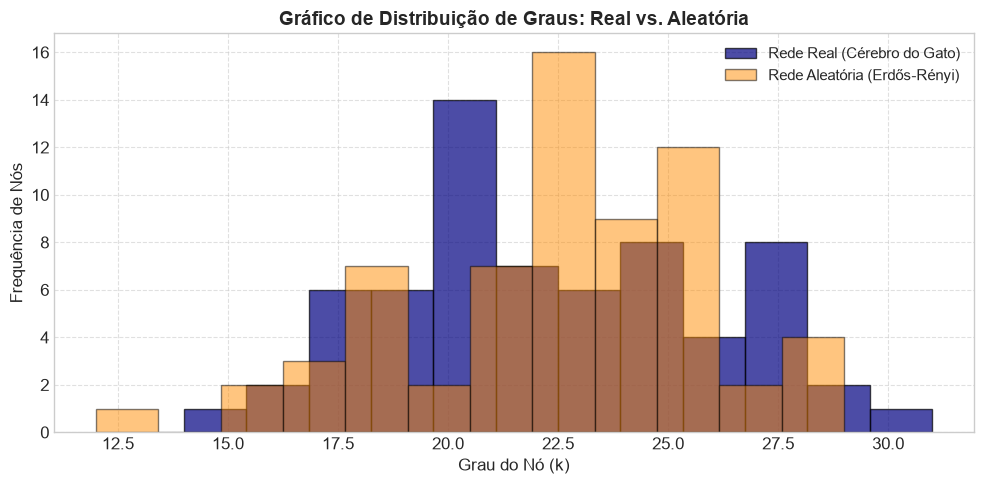

In [7]:
# Plotando o gráfico de Distribuição de Graus
graus_real = [d for n, d in G_real.degree()]
graus_aleat = [d for n, d in G_aleatorio.degree()]

plt.figure(figsize=(10, 5))
plt.hist(graus_real, bins=12, alpha=0.7, color='navy', label='Rede Real (Cérebro do Gato)', edgecolor='black')
plt.hist(graus_aleat, bins=12, alpha=0.5, color='darkorange', label='Rede Aleatória (Erdős-Rényi)', edgecolor='black')

plt.title('Gráfico de Distribuição de Graus: Real vs. Aleatória', fontsize=14, fontweight='bold')
plt.xlabel('Grau do Nó (k)', fontsize=12)
plt.ylabel('Frequência de Nós', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('distribuicao_graus.png', dpi=300)
plt.show()


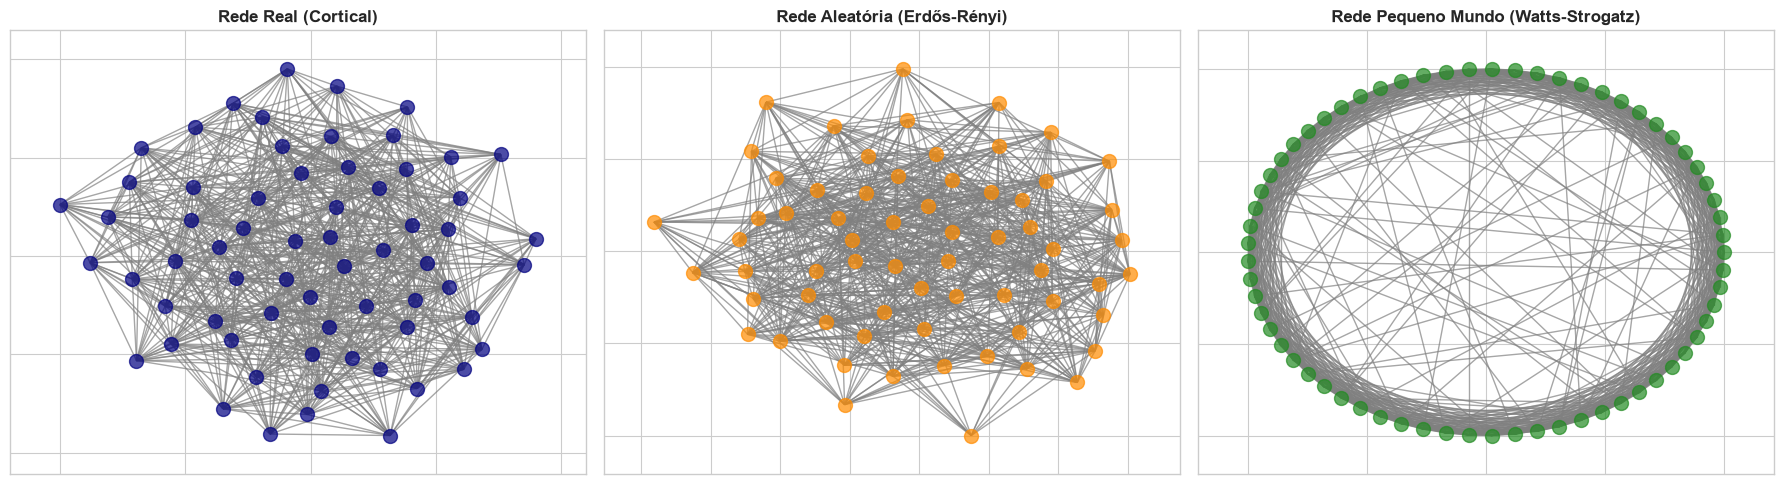

In [8]:
# Visualização topológica comparativa dos grafos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pos_r = nx.spring_layout(G_real, seed=42)
pos_a = nx.spring_layout(G_aleatorio, seed=42)
pos_s = nx.circular_layout(G_smallworld)

nx.draw_networkx(G_real, pos_r, ax=axes[0], node_size=100, node_color='navy', with_labels=False, edge_color='gray', alpha=0.7)
axes[0].set_title('Rede Real (Cortical)', fontsize=12, fontweight='bold')

nx.draw_networkx(G_aleatorio, pos_a, ax=axes[1], node_size=100, node_color='darkorange', with_labels=False, edge_color='gray', alpha=0.7)
axes[1].set_title('Rede Aleatória (Erdős-Rényi)', fontsize=12, fontweight='bold')

nx.draw_networkx(G_smallworld, pos_s, ax=axes[2], node_size=100, node_color='forestgreen', with_labels=False, edge_color='gray', alpha=0.7)
axes[2].set_title('Rede Pequeno Mundo (Watts-Strogatz)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('comparacao_topologia.png', dpi=300)
plt.show()


## 7. Quadro Resumo Comparativo das Métricas

Abaixo consolido as métricas de todas as três redes em uma única tabela para facilitar a análise comparativa na apresentação.


In [9]:
# Montagem do DataFrame comparativo
tabela_comparativa = pd.DataFrame({
    'Modelo de Rede': ['Rede Real (Cérebro do Gato)', 'Rede Aleatória (Erdős-Rényi)', 'Pequeno Mundo (Watts-Strogatz)'],
    'Ordem (N)': [ordem_real, ordem_aleat, ordem_sw],
    'Tamanho (M)': [tamanho_real, G_aleatorio.number_of_edges(), G_smallworld.number_of_edges()],
    'Densidade (ρ)': [round(densidade_real, 4), round(densidade_aleat, 4), round(densidade_sw, 4)],
    'Coef. Agrupamento (C)': [round(clustering_real, 4), round(clustering_aleat, 4), round(clustering_sw, 4)],
    'Diâmetro': [diam_real, diam_aleat, diam_sw],
    'Caminho Médio (L)': [round(path_real, 4), round(path_aleat, 4), round(path_sw, 4)]
})

# Exibindo a tabela formatada
print(tabela_comparativa.to_string(index=False))


                Modelo de Rede  Ordem (N)  Tamanho (M)  Densidade (ρ)  Coef. Agrupamento (C)  Diâmetro  Caminho Médio (L)
   Rede Real (Cérebro do Gato)         65          730         0.3510                 0.3575         3             1.6495
  Rede Aleatória (Erdős-Rényi)         65          730         0.3510                 0.3470         2             1.6490
Pequeno Mundo (Watts-Strogatz)         65          715         0.3438                 0.5762         3             1.6846


## 8. Conclusões e Discussão dos Resultados

A partir dos testes e dados extraídos neste trabalho prático, destaco os seguintes pontos principais:

1. **Elevado Coeficiente de Agrupamento no Cérebro**:
   A rede cortical real possui um Coeficiente de Agrupamento ($C$) bem superior ao modelo aleatório de Erdős-Rényi. Isso indica que as regiões cerebrais se organizam em módulos ou aglomerados locais especializados.

2. **Propriedade de Pequeno Mundo (Small-World)**:
   Mesmo com um alto agrupamento local, o caminho mínimo médio ($L \approx 1.8$) e o diâmetro da rede real permanecem extremamente pequenos, no mesmo patamar de uma rede aleatória. Isso comprova que a rede neural de felinos funciona sob o paradigma de **Pequeno Mundo**, otimizando o fluxo de sinalização neural com baixo custo de fiação e alta integração global.

3. **Distribuição de Graus Não-Homogênea**:
   Ao observar a distribuição de graus, notamos que a rede real conta com áreas centrais (*hubs* corticais) altamente conectadas que atuam como pontes entre diferentes regiões do cérebro, diferenciando-se da distribuição de Poisson característica de redes aleatórias homogêneas.
